In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import os
from PIL import Image
import snntorch as snn
from snntorch import surrogate
from sklearn.preprocessing import LabelEncoder
from snntorch import utils
from scipy.interpolate import CubicSpline

In [ ]:
DATA_DIR = "../../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [ ]:
# data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [ ]:
# label_mapping = {
#     'Benign': 'Benign',
#     'Bot': 'Botnet',
#     'FTP-BruteForce': 'Brute Force',
#     'SSH-Bruteforce': 'Brute Force',
#     'DDoS attacks-LOIC-HTTP': 'DDoS',
#     'DDOS attack-LOIC-UDP': 'DDoS',
#     'DDOS attack-HOIC': 'DDoS',
#     'DoS attacks-GoldenEye': 'DoS',
#     'DoS attacks-Slowloris': 'DoS',
#     'DoS attacks-SlowHTTPTest': 'DoS',
#     'DoS attacks-Hulk': 'DoS',
#     'Infilteration': 'Infiltration',
#     'Brute Force -Web': 'Brute Force',
#     'Brute Force -XSS': 'Brute Force',
#     'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
# }

# data["Label"] = data["Label"].map(label_mapping)

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [ ]:
train_df = pd.read_csv(f"{DATASET_DIR}/train1.csv")
test_df = pd.read_csv(f"{DATASET_DIR}/test1.csv")
val_df = pd.read_csv(f"{DATASET_DIR}/val1.csv")

In [ ]:
# shuffle val and test
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

# LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=transform)

In [ ]:
from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

labels = train_df_encoded["Label"].values
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(labels), y=labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [ ]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class SNNClassifier(nn.Module):
    def __init__(self, num_classes=2, time_steps=4, threshold=0.3, alpha=0.5):
        super(SNNClassifier, self).__init__()
        self.time_steps = time_steps
        
        # Spiking layers
        self.conv1 = ConvSpikingLayer(1, 16, 4, 4, threshold, alpha)
        self.conv2 = ConvSpikingLayer(16, 32, 2, 2, threshold, alpha)
        
        # Time-value encoder
        self.encoder = TimeValEncoder(time_steps)
        
        # Classifier
        self.fc = nn.Linear(32*4*4, num_classes)
        
        # State trackers
        self.spk1 = self.spk2 = None
        self.mem1 = self.mem2 = None

    def forward(self, x):
        # Add time dimension: (B,C,H,W) → (T,B,C,H,W)
        x = x.unsqueeze(0).repeat(self.time_steps, 1, 1, 1, 1)
        
        # Process through layers
        spk1, mem1 = self.conv1(x)
        spk2, mem2 = self.conv2(spk1)
        
        # Temporal encoding
        encoded = self.encoder(spk2)


        self.spk1 = spk1
        self.spk2 = spk2
        self.mem1 = mem1
        self.mem2 = mem2
        
        out = self.fc(encoded.flatten(1))
        return out

class ConvSpikingLayer(nn.Module):
    """Single convolutional spiking layer with document-specific reset"""
    def __init__(self, in_channels, out_channels, kernel_size, stride, threshold=0.3, alpha=0.3):
        super(ConvSpikingLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size,
                              stride, padding='valid')
        
        self.lif = snn.Leaky(
            beta=1.0,  # No leakage: V(t) = V(t-1) + I(t)
            threshold=threshold,
            reset_mechanism="none",  # Disable built-in reset
            spike_grad=surrogate.fast_sigmoid(slope=25),
            output=True
        )
        self.alpha = alpha

    def forward(self, x):
        """Input shape: (T, B, C, H, W)"""
        time_steps, batch_size = x.shape[:2]
        spk_rec = []
        mem_rec = []

        mem = self.lif.reset_mem()
        
        for t in range(time_steps):
            conv_out = self.conv(x[t])
            spk, mem = self.lif(conv_out, mem)
            
            # Document-specific reset: (V - V_thr) * α
            mem = torch.where(spk > 0,(mem - self.lif.threshold) * self.alpha, mem)
            
            # clamp negative values to zero
            # mem = F.relu(mem)
            
            spk_rec.append(spk)
            mem_rec.append(mem)
            
        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

class TimeValEncoder(nn.Module):
    def __init__(self, time_steps):
        super(TimeValEncoder, self).__init__()
        weights = [2**(time_steps-i-1) for i in range(time_steps)]
        weights = torch.tensor(weights, dtype=torch.float32)
        self.weights = nn.Parameter(weights/weights.sum(), requires_grad=False)

    def forward(self, x):
        # x: (time_steps, batch_size, channels, height, width)
        return torch.einsum('tb...,t->b...', x, self.weights.to(x.device))
    
class CustomLoss(nn.Module):
    def __init__(self, num_classes, class_weights=None):
        super(CustomLoss, self).__init__()
        self.n_classes = num_classes
        self.class_weights = class_weights

    def forward(self, predict, target):
        predict = torch.log_softmax(predict, dim=1)

        # Convert targets to one-hot encoding (if needed)
        if target.dim() == 1 or target.size(1) != self.n_classes:
            target_onehot = torch.zeros_like(predict).scatter(1, target.unsqueeze(1), 1)
        else:
            target_onehot = target  # Assume already one-hot
        
        # 1. Compute α term (difference between max prediction and correct class score)
        cor = (predict * target_onehot).sum(dim=1)  # Correct class scores
        pre = predict.max(dim=1)[0]                 # Max prediction scores
        alpha = pre - cor

        # 2. Compute β term (ranking penalty)
        val = predict.gather(1, target.unsqueeze(1)).squeeze()  # Correct class values
        ids = (predict > val.unsqueeze(1)).sum(dim=1).float()   # Number of classes ranked higher
        beta = 1 - cor

        # 3. loss (Eq. in Algorithm 2) 
        loss = (self.n_classes * alpha + (ids + 1) * beta)

        # if class weights are provided, apply them
        if self.class_weights is not None:
            loss *= self.class_weights[target]

        return loss.mean()
    

class CubicSplineThreshold:
    def __init__(self, scaling_factor=10):  # Document-specified default
        self.scaling_factor = scaling_factor

    def compute_threshold(self, mem_rec):
        """
        Pure implementation of document's Section 3.2 and Equations 7-10
        mem_rec: (T, B, C, H, W) membrane potentials
        """
        # Document specifies using first sample only
        mem_sample = mem_rec[:, 0].detach().flatten().cpu().numpy()
        
        # Document's exact spline fitting logic (Eq. 7-8)
        x = np.arange(len(mem_sample))
        cs = CubicSpline(x, mem_sample)
        
        # Document's slope calculation (Eq. 9-10)
        derivatives = cs(x, 1)  # First derivative
        avg_slope = np.mean(np.abs(derivatives))
        
        # Document-specified clipping (Sec 3.2)
        return float(np.clip(avg_slope * self.scaling_factor, 0.1, 5.0))

In [ ]:
dummy = torch.randn(1, 1, 32, 32)
model = SNNClassifier(num_classes=2, time_steps=4)
outputs = model(dummy)

spk1 = model.spk1
spk2 = model.spk2

torch.softmax(outputs, dim=1), outputs

model.mem1.shape, model.mem2.shape

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_class_metrics(y_true, y_pred):

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'benign': {
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [91]:
def train_model(train_dataloader, val_dataloader, num_classes=6, lr=1e-3, weight_decay=None, 
                num_epochs=50, model_savepath=None, device="cuda", dt_ms=1.0, class_weights=None):
    # Initialize model
    model = SNNClassifier(num_classes=num_classes, time_steps=4).to(device)
    loss_fn = CustomLoss(num_classes=num_classes, class_weights=class_weights)
    
    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=lr,
        weight_decay=weight_decay if weight_decay else 0,
        betas=(0.9, 0.999)
    )
    
    # Scheduler
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda epoch: 0.5 * (1 + np.cos((epoch / num_epochs) * np.pi)) 
        if epoch > 0 else 1.0
    )

    # Updated metrics tracking dictionary (similar to train_model2)
    metrics = {
        'train': {
            'loss': [],           # Per batch loss
            'avg_loss': [],       # Per epoch average loss
            'acc': [],            # Per epoch accuracy
            'f1': [],             # Per epoch overall F1 (if needed)
            'class_metrics': [],  # Per epoch class-specific metrics (if needed)
        },
        'val': {
            'loss': [],
            'avg_loss': [],
            'acc': [],
            'f1': [],
            'class_metrics': [],
        },
        # Spike statistics
        'spike_stats': {
            'train': {
                'avg_spikes_per_neuron': [],
                'spike_rate_hz': [],
                'spike_count': [],
                'active_neurons_percent': [],
                'threshold_proximity_avg': [],
                'threshold_proximity_std': [],
                'membrane_potential_avg': [],
                'membrane_potential_std': [],
            },
            'val': {
                'avg_spikes_per_neuron': [],
                'spike_rate_hz': [],
                'spike_count': [],
                'active_neurons_percent': [],
                'threshold_proximity_avg': [],
                'threshold_proximity_std': [],
                'membrane_potential_avg': [],
                'membrane_potential_std': [],
            },
            'firing_rate_stability': [], # General stability metric
        },
    }


    best_val_f1 = -1
    best_model_state = None
    neuron_cache = {'conv1': None, 'conv2': None}
    threshold_fn = CubicSplineThreshold()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # --- TRAINING PHASE ---
        model.train()
        
        # Per-epoch tracking
        epoch_data = {
            'train_loss': 0,
            'train_correct': 0,
            'train_total': 0,
            'spike_count': 0,
            'active_neurons': 0,
            'total_neurons': 0,
            'total_possible': 0,
            'train_preds': [],
            'train_targets': [],
            'membrane_sum': 0.0,
            'membrane_sq_sum': 0.0,
            'total_mem_samples': 0,
            'proximity_sum': 0.0,
            'proximity_sq_sum': 0.0,
            'proximity_samples': 0,
        }

        for data, targets in tqdm(train_dataloader, desc="Training"):
            data, targets = data.to(device), targets.to(device)
            utils.reset(model)
            
            # Forward pass
            outputs = model(data)
            spk1, spk2 = model.spk1, model.spk2

            # Cache neuron counts on first batch
            if neuron_cache['conv1'] is None:
                with torch.no_grad():
                    neuron_cache['conv1'] = spk1[0, 0].numel()  # e.g., 16*8*8
                    neuron_cache['conv2'] = spk2[0, 0].numel()  # e.g., 32*4*4

            # Get cached values (conv layers only)
            nl1 = neuron_cache['conv1']
            nl2 = neuron_cache['conv2']
            
            # Dynamic threshold calculation
            thresh_conv1 = threshold_fn.compute_threshold(model.mem1)
            thresh_conv2 = threshold_fn.compute_threshold(model.mem2)

            # Loss calculation
            loss = loss_fn(outputs, targets)
            epoch_data['train_loss'] += loss.item()
            metrics['train']['loss'].append(loss.item())

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.conv1.parameters(), thresh_conv1)
            torch.nn.utils.clip_grad_norm_(model.conv2.parameters(), thresh_conv2)
            optimizer.step()

            # --- METRICS CALCULATION ---
            with torch.no_grad():
                batch_size = data.size(0)
                time_steps = model.time_steps
                
                # Accuracy
                predicted = torch.argmax(outputs, dim=1)
                epoch_data['train_correct'] += (predicted == targets).sum().item()
                epoch_data['train_total'] += targets.size(0)
                
                # Store predictions for F1 calculation
                epoch_data['train_preds'].append(predicted.cpu())
                epoch_data['train_targets'].append(targets.cpu())
                
                # Total neurons calculation (conv layers only)
                total_neurons_batch = (nl1 + nl2) * batch_size * time_steps
                epoch_data['total_neurons'] += total_neurons_batch
                
                # Spike counts (conv layers only)
                batch_spike_count = (spk1.sum() + spk2.sum()).item()
                epoch_data['spike_count'] += batch_spike_count
                
                # Active neurons calculation (conv layers only)
                active_conv1 = (spk1.sum(dim=0) > 0).sum().item()
                active_conv2 = (spk2.sum(dim=0) > 0).sum().item()
                epoch_data['active_neurons'] += active_conv1 + active_conv2

                # Total active neurons possible
                total_active_neurons_possible = (nl1 + nl2) * batch_size
                epoch_data['total_possible'] += total_active_neurons_possible

                # Membrane stats (conv layers only)
                mem = torch.cat([model.mem1.flatten(), model.mem2.flatten()])
                epoch_data['membrane_sum'] += mem.sum().item()
                epoch_data['membrane_sq_sum'] += (mem**2).sum().item()
                epoch_data['total_mem_samples'] += mem.numel()
                
                # Dynamic threshold proximity calculation
                prox_conv1 = torch.abs(model.mem1 - model.conv1.lif.threshold)
                prox_conv2 = torch.abs(model.mem2 - model.conv2.lif.threshold)
                proximity = torch.cat([prox_conv1.flatten(), prox_conv2.flatten()])
                epoch_data['proximity_sum'] += proximity.sum().item()
                epoch_data['proximity_sq_sum'] += (proximity**2).sum().item()
                epoch_data['proximity_samples'] += proximity.numel()

        # --- EPOCH STATISTICS ---
        avg_train_loss = epoch_data['train_loss'] / len(train_dataloader)
        metrics['train']['avg_loss'].append(avg_train_loss)
        
        train_acc = epoch_data['train_correct'] / epoch_data['train_total'] if epoch_data['train_total'] > 0 else 0
        metrics['train']['acc'].append(train_acc)
        
        # Calculate F1 and class metrics if needed
        train_preds = torch.cat(epoch_data['train_preds']).numpy() if epoch_data['train_preds'] else np.array([])
        train_targets = torch.cat(epoch_data['train_targets']).numpy() if epoch_data['train_targets'] else np.array([])
        
        
        train_f1 = f1_score(train_targets, train_preds, average="weighted") if len(train_preds) > 0 else 0.0
        
        # Calculate class-specific metrics
        if len(train_preds) > 0:
            train_class_metrics = calculate_class_metrics(train_targets, train_preds)
            metrics['train']['class_metrics'].append(train_class_metrics)
        else:
            train_class_metrics = {
                'benign': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
                'malicious': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
            }
            
        metrics['train']['f1'].append(train_f1)
        metrics['train']['class_metrics'].append(train_class_metrics)
        
        # Calculate spike statistics
        avg_spikes = epoch_data['spike_count'] / epoch_data['total_neurons'] if epoch_data['total_neurons'] > 0 else 0
        active_percent = (epoch_data['active_neurons'] / epoch_data['total_possible']) * 100 if epoch_data['total_possible'] > 0 else 0

        # Calculate membrane potential statistics
        mem_avg = epoch_data['membrane_sum'] / epoch_data['total_mem_samples'] if epoch_data['total_mem_samples'] > 0 else 0
        mem_std = np.sqrt(epoch_data['membrane_sq_sum'] / epoch_data['total_mem_samples'] - mem_avg**2) if epoch_data['total_mem_samples'] > 0 else 0
        
        # Calculate threshold proximity statistics
        prox_avg = epoch_data['proximity_sum'] / epoch_data['proximity_samples'] if epoch_data['proximity_samples'] > 0 else 0
        prox_std = np.sqrt(epoch_data['proximity_sq_sum'] / epoch_data['proximity_samples'] - prox_avg**2) if epoch_data['proximity_samples'] > 0 else 0

        # Update spike statistics history
        metrics['spike_stats']['train']['avg_spikes_per_neuron'].append(avg_spikes)
        metrics['spike_stats']['train']['spike_rate_hz'].append(avg_spikes * (1000/dt_ms))
        metrics['spike_stats']['train']['spike_count'].append(epoch_data['spike_count'])
        metrics['spike_stats']['train']['active_neurons_percent'].append(active_percent)
        metrics['spike_stats']['train']['membrane_potential_avg'].append(mem_avg)
        metrics['spike_stats']['train']['membrane_potential_std'].append(mem_std)
        metrics['spike_stats']['train']['threshold_proximity_avg'].append(prox_avg)
        metrics['spike_stats']['train']['threshold_proximity_std'].append(prox_std)

        print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2%}")
        print(f"Spike Rate: {avg_spikes*(1000/dt_ms):.1f}Hz | Active Neurons: {active_percent:.1f}%")
        print(f"Membrane Potential: {mem_avg:.4f} ± {mem_std:.4f}")
        print(f"Threshold Proximity: {prox_avg:.4f} ± {prox_std:.4f}")

        # --- VALIDATION PHASE ---
        with torch.no_grad():
            model.eval()
            
            # Per-epoch validation tracking
            val_data = {
                'val_loss': 0,
                'val_correct': 0,
                'val_total': 0,
                'spike_count': 0,
                'active_neurons': 0,
                'total_neurons': 0,
                'total_possible': 0,
                'val_preds': [],
                'val_targets': [],
                'membrane_sum': 0.0,
                'membrane_sq_sum': 0.0,
                'total_mem_samples': 0,
                'proximity_sum': 0.0,
                'proximity_sq_sum': 0.0,
                'proximity_samples': 0,
            }
            
            for data, targets in tqdm(val_dataloader, desc="Validation"):
                data, targets = data.to(device), targets.to(device)
                utils.reset(model)
                
                outputs = model(data)
                spk1, spk2 = model.spk1, model.spk2
                
                # Loss and accuracy
                loss = loss_fn(outputs, targets)
                val_data['val_loss'] += loss.item()
                metrics['val']['loss'].append(loss.item())

                # Accuracy
                predicted = torch.argmax(outputs, dim=1)
                val_data['val_correct'] += (predicted == targets).sum().item()
                val_data['val_total'] += targets.size(0)
                
                # Store predictions for F1 calculation
                val_data['val_preds'].append(predicted.cpu())
                val_data['val_targets'].append(targets.cpu())

                # Spike statistics
                batch_size = data.size(0)
                time_steps = model.time_steps
                nl1 = neuron_cache['conv1']
                nl2 = neuron_cache['conv2']

                # Total neurons (conv layers only)
                total_neurons_batch = (nl1 + nl2) * batch_size * time_steps
                val_data['total_neurons'] += total_neurons_batch
                
                # Spike counts (conv layers only)
                val_data['spike_count'] += (spk1.sum() + spk2.sum()).item()
                
                # Active neurons (conv layers only)
                active_conv1 = (spk1.sum(dim=0) > 0).sum().item()
                active_conv2 = (spk2.sum(dim=0) > 0).sum().item()
                val_data['active_neurons'] += active_conv1 + active_conv2
                
                # Total active neurons possible
                total_active_neurons_possible = (nl1 + nl2) * batch_size
                val_data['total_possible'] += total_active_neurons_possible

                # Membrane stats
                mem = torch.cat([model.mem1.flatten(), model.mem2.flatten()])
                val_data['membrane_sum'] += mem.sum().item()
                val_data['membrane_sq_sum'] += (mem**2).sum().item()
                val_data['total_mem_samples'] += mem.numel()
                
                # Dynamic threshold proximity calculation
                prox_conv1 = torch.abs(model.mem1 - model.conv1.lif.threshold)
                prox_conv2 = torch.abs(model.mem2 - model.conv2.lif.threshold)
                proximity = torch.cat([prox_conv1.flatten(), prox_conv2.flatten()])
                val_data['proximity_sum'] += proximity.sum().item()
                val_data['proximity_sq_sum'] += (proximity**2).sum().item()
                val_data['proximity_samples'] += proximity.numel()

        # --- VALIDATION METRICS ---
        avg_val_loss = val_data['val_loss'] / len(val_dataloader)
        val_acc = val_data['val_correct'] / val_data['val_total'] if val_data['val_total'] > 0 else 0
        
        metrics['val']['avg_loss'].append(avg_val_loss)
        metrics['val']['acc'].append(val_acc)

        # Calculate F1 and class metrics if needed
        val_preds = torch.cat(val_data['val_preds']).numpy() if val_data['val_preds'] else np.array([])
        val_targets = torch.cat(val_data['val_targets']).numpy() if val_data['val_targets'] else np.array([])
        
        
        # Overall F1 score (binary average)
        val_f1 = f1_score(val_targets, val_preds, average='weighted') if len(val_preds) > 0 else 0.0
        metrics['val']['f1'].append(val_f1)
        
        # Calculate class-specific metrics
        if len(val_preds) > 0:
            val_class_metrics = calculate_class_metrics(val_targets, val_preds)
            metrics['val']['class_metrics'].append(val_class_metrics)
        else:
            val_class_metrics = {
                'benign': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0},
                'malicious': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
            }
            metrics['val']['class_metrics'].append(val_class_metrics)


        # Calculate validation spike statistics
        val_avg_spikes = val_data['spike_count'] / val_data['total_neurons'] if val_data['total_neurons'] > 0 else 0
        val_active_percent = (val_data['active_neurons'] / val_data['total_possible']) * 100 if val_data['total_possible'] > 0 else 0
        
        # Calculate membrane statistics
        val_mem_avg = val_data['membrane_sum'] / val_data['total_mem_samples'] if val_data['total_mem_samples'] > 0 else 0
        val_mem_std = np.sqrt(val_data['membrane_sq_sum'] / val_data['total_mem_samples'] - val_mem_avg**2) if val_data['total_mem_samples'] > 0 else 0
        
        # Calculate threshold proximity statistics
        val_prox_avg = val_data['proximity_sum'] / val_data['proximity_samples'] if val_data['proximity_samples'] > 0 else 0
        val_prox_std = np.sqrt(val_data['proximity_sq_sum'] / val_data['proximity_samples'] - val_prox_avg**2) if val_data['proximity_samples'] > 0 else 0

        # Update validation spike statistics history
        metrics['spike_stats']['val']['avg_spikes_per_neuron'].append(val_avg_spikes)
        metrics['spike_stats']['val']['spike_rate_hz'].append(val_avg_spikes * (1000/dt_ms))
        metrics['spike_stats']['val']['spike_count'].append(val_data['spike_count'])
        metrics['spike_stats']['val']['active_neurons_percent'].append(val_active_percent)
        metrics['spike_stats']['val']['membrane_potential_avg'].append(val_mem_avg)
        metrics['spike_stats']['val']['membrane_potential_std'].append(val_mem_std)
        metrics['spike_stats']['val']['threshold_proximity_avg'].append(val_prox_avg)
        metrics['spike_stats']['val']['threshold_proximity_std'].append(val_prox_std)

        # Model checkpointing
        # use f1 score as the metric to save the best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': avg_val_loss,
                'val_acc': val_acc,
                'val_f1': val_f1,
            }
            print(f"New best model found! Val F1: {val_f1:.4f}")

        print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2%} | Val F1: {val_f1:.4f}")
        print(f"Val Spike Rate: {val_avg_spikes*(1000/dt_ms):.1f}Hz | Active Neurons: {val_active_percent:.1f}%")
        print(f"Benign - P: {val_class_metrics['benign']['precision']:.4f}, R: {val_class_metrics['benign']['recall']:.4f}, F1: {val_class_metrics['benign']['f1']:.4f}")
        print(f"Malicious - P: {val_class_metrics['malicious']['precision']:.4f}, R: {val_class_metrics['malicious']['recall']:.4f}, F1: {val_class_metrics['malicious']['f1']:.4f}")
        print(f"Membrane Potential: Train {mem_avg:.4f} ± {mem_std:.4f} | Val {val_mem_avg:.4f} ± {val_mem_std:.4f}")
        print(f"Threshold Proximity: Train {prox_avg:.4f} ± {prox_std:.4f} | Val {val_prox_avg:.4f} ± {val_prox_std:.4f}")
        print("-" * 50)

        # Update scheduler
        scheduler.step()

    # Final saving
    if model_savepath:
        final_state = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': metrics
        }
        torch.save(final_state, model_savepath)
        
        if best_model_state is not None:
            best_path = model_savepath.replace(".pt", "_best.pt")
            torch.save(best_model_state, best_path)
            print(f"Best model (F1: {best_val_f1:.4f}) saved at {best_path}")

    return model, metrics

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_df_encoded["Label"]), y=train_df_encoded["Label"])
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

class_weights

In [ ]:
base_dir = "../../models/checkpoints/paper_snn"
path = f"{base_dir}/modelv3.pt"

os.makedirs(base_dir, exist_ok=True)
model_savepath = path

In [92]:
model, history = train_model(train_data_loader, val_data_loader, num_epochs=50, lr=0.001, weight_decay=0, num_classes=2, model_savepath=model_savepath, device=device, dt_ms=1.0, class_weights=class_weights)

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:41<00:00, 18.19it/s]


Train Loss: 2.6049 | Train Acc: 86.50%
Spike Rate: 197.9Hz | Active Neurons: 38.2%
Membrane Potential: -0.1212 ± 0.3669
Threshold Proximity: 0.4221 ± 0.3659


Validation: 100%|██████████| 750/750 [00:39<00:00, 18.85it/s]


New best model found! Val F1: 0.8491
Val Loss: 1.8121 | Val Acc: 83.02% | Val F1: 0.8491
Val Spike Rate: 195.1Hz | Active Neurons: 37.9%
Benign - P: 0.4953, R: 0.9920, F1: 0.6607
Malicious - P: 0.9980, R: 0.7978, F1: 0.8867
Membrane Potential: Train -0.1212 ± 0.3669 | Val -0.1178 ± 0.3707
Threshold Proximity: Train 0.4221 ± 0.3659 | Val 0.4188 ± 0.3696
--------------------------------------------------
Epoch 2/50
--------------------------------------------------


...

Val Loss: 1.6785 | Val Acc: 86.40% | Val F1: 0.8768
Val Spike Rate: 148.3Hz | Active Neurons: 25.0%
Benign - P: 0.5532, R: 0.9574, F1: 0.7012
Malicious - P: 0.9900, R: 0.8453, F1: 0.9120
Membrane Potential: Train -0.3424 ± 0.7147 | Val -0.3373 ± 0.7064
Threshold Proximity: Train 0.6459 ± 0.7115 | Val 0.6402 ± 0.7038
--------------------------------------------------
Epoch 50/50
--------------------------------------------------


Training: 100%|██████████| 750/750 [00:55<00:00, 13.52it/s]


Train Loss: 2.2510 | Train Acc: 92.54%
Spike Rate: 150.5Hz | Active Neurons: 25.2%
Membrane Potential: -0.3426 ± 0.7148
Threshold Proximity: 0.6461 ± 0.7116


Validation: 100%|██████████| 750/750 [00:44<00:00, 16.95it/s]


Val Loss: 1.6794 | Val Acc: 86.39% | Val F1: 0.8767
Val Spike Rate: 148.3Hz | Active Neurons: 25.0%
Benign - P: 0.5529, R: 0.9578, F1: 0.7011
Malicious - P: 0.9901, R: 0.8451, F1: 0.9119
Membrane Potential: Train -0.3426 ± 0.7148 | Val -0.3373 ± 0.7064
Threshold Proximity: Train 0.6461 ± 0.7116 | Val 0.6402 ± 0.7038
--------------------------------------------------
Best model (F1: 0.8812) saved at ../../models/checkpoints/paper_snn/modelv3_best.pt


In [93]:
test_df_encoded = test_df.copy()
test_df_encoded["Label"] = LE.transform(test_df_encoded["Label"])

test_dataset = CustomDataset(test_df_encoded, f"{DATASET_DIR}/images", transform=transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [94]:
# sample 12000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_df_encoded.groupby("Label").sample(6000, random_state=42)

# shuffle the data
test_data_sample = test_data_sample.sample(frac=1, random_state=42).reset_index(drop=True) 

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

In [95]:
best_model_path  = f"{base_dir}/modelv1_best.pt"

checkpoint = torch.load(best_model_path, weights_only=False)
best_model = SNNClassifier(num_classes=2, time_steps=4).to(device)
best_model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [96]:
from sklearn.metrics import classification_report
def calculate_accuracy2(model, test_data_loader_sample, device, class_names=None):
    y_true = torch.tensor([], dtype=torch.long, device=device)
    y_pred = torch.tensor([], dtype=torch.long, device=device)

    with torch.no_grad():
        model.eval()
        for data, targets in tqdm(test_data_loader_sample, desc="Testing"):
            data, targets = data.to(device), targets.to(device)
            utils.reset(model)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            y_true = torch.cat([y_true, targets])
            y_pred = torch.cat([y_pred, predicted])

    if class_names is not None:
        print(classification_report(y_true.cpu().numpy(), y_pred.cpu().numpy(), target_names=class_names))

    return y_true, y_pred

y_true, y_pred = calculate_accuracy2(best_model, test_data_loader_sample, device, class_names=LE.classes_)

Testing: 100%|██████████| 300/300 [00:17<00:00, 17.63it/s]

              precision    recall  f1-score   support

   Malicious       0.97      0.93      0.95      6000
      Benign       0.93      0.97      0.95      6000

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



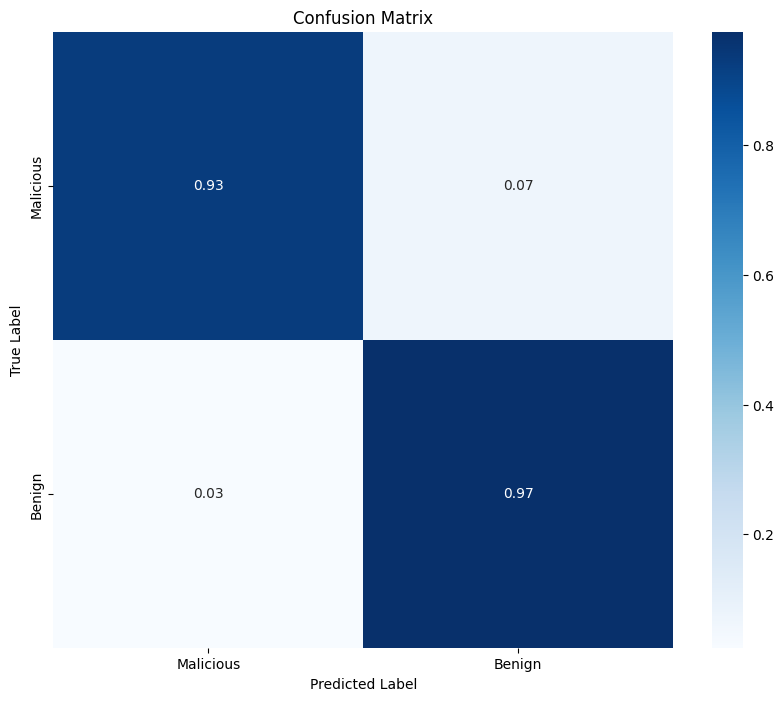

              precision    recall  f1-score   support

   Malicious       0.97      0.93      0.95      6000
      Benign       0.93      0.97      0.95      6000

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



In [97]:
def plot_cm(y_true, y_pred, classes, title='Confusion Matrix'):
    """Plot confusion matrix."""
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    import matplotlib.pyplot as plt

    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


    class_report = classification_report(y_true, y_pred, target_names=classes)
    print(class_report)

plot_cm(y_true, y_pred, LE.classes_, title='Confusion Matrix')